# Entropy Normalization: Invariant Measure vs Standard Deviation

Both the `entropy-invariant` package and scikit-learn achieve scale invariance by
**normalizing** data before computing k-NN distances. But they use different normalizations:

| | sklearn | entropy-invariant |
|---|---|---|
| **Normalization** | Divide by `std(X)` (global L2 statistic) | Divide by `median(nn_dist) * n` (local non-parametric statistic) |
| **Applied to** | MI only (as preprocessing in `_estimate_mi`) | Entropy directly (inside `entropy_inv`) |
| **Algorithm** | KSG estimator (Kraskov et al. 2004) | Kozachenko-Leonenko k-NN estimator |

This notebook explores: **does it matter which normalization you use?**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from entropy_invariant import entropy
from entropy_invariant.helpers.computation import compute_invariant_measure

## Helper: k-NN entropy after dividing by std

sklearn doesn't expose a standalone entropy function, so we replicate its
preprocessing: divide by `std(X)`, then compute k-NN entropy.

In [2]:
def entropy_std_normalized(x, k=3):
    """k-NN entropy after sklearn-style normalization (divide by std)."""
    s = np.std(x)
    if s == 0:
        return np.nan
    return entropy(x / s, method="knn", k=k)

## 1. Both are scale-invariant

First, let's confirm that both normalizations make entropy independent of scale.

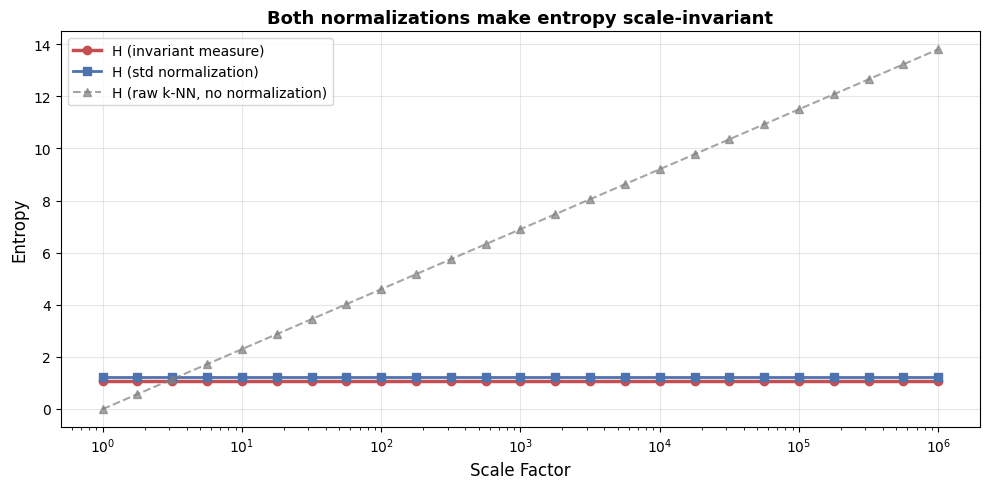

In [3]:
np.random.seed(0)
n = 1000
x = np.random.rand(n)

scale_factors = np.logspace(0, 6, 25)
h_inv = [entropy(s * x, method="inv") for s in scale_factors]
h_std = [entropy_std_normalized(s * x) for s in scale_factors]
h_raw = [entropy(s * x, method="knn") for s in scale_factors]

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogx(scale_factors, h_inv, "o-", label="H (invariant measure)", color="#C44E52", linewidth=2.5)
ax.semilogx(scale_factors, h_std, "s-", label="H (std normalization)", color="#4C72B0", linewidth=2)
ax.semilogx(scale_factors, h_raw, "^--", label="H (raw k-NN, no normalization)", color="gray", linewidth=1.5, alpha=0.7)
ax.set_xlabel("Scale Factor", fontsize=12)
ax.set_ylabel("Entropy", fontsize=12)
ax.set_title("Both normalizations make entropy scale-invariant", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Where they diverge: non-Gaussian distributions

`std` is a global L2 statistic dominated by outliers and heavy tails.
`median(nn_dist) * n` measures the **typical local spacing** between points.

These give very different normalizations when the distribution is skewed or heavy-tailed.

In [4]:
np.random.seed(42)
n = 2000

distributions = {
    "Uniform [0,1]": np.random.rand(n),
    "Normal(0,1)": np.random.randn(n),
    "Exponential(1)": np.random.exponential(1, n),
    "Log-normal(0,2)": np.random.lognormal(0, 2, n),
    "Pareto(2)": (np.random.pareto(2, n) + 1),
    "Beta(0.5, 0.5)": np.random.beta(0.5, 0.5, n),
    "Mixture: N(0,1) + 1% outliers at 100": np.where(
        np.random.rand(n) < 0.99, np.random.randn(n), 100 + np.random.randn(n)
    ),
}

names = list(distributions.keys())
h_inv_vals = []
h_std_vals = []
h_raw_vals = []

print(f"{'Distribution':<40} {'std':>8} {'r_X':>10} {'ratio':>8} {'H(inv)':>8} {'H(std)':>8} {'H(raw)':>8}")
print("-" * 95)
for name, x in distributions.items():
    std_x = np.std(x)
    r_x = compute_invariant_measure(x)
    h_i = entropy(x, method="inv")
    h_s = entropy_std_normalized(x)
    h_r = entropy(x, method="knn")
    h_inv_vals.append(h_i)
    h_std_vals.append(h_s)
    h_raw_vals.append(h_r)
    print(f"{name:<40} {std_x:>8.2f} {r_x:>10.4f} {std_x/r_x:>8.1f} {h_i:>8.4f} {h_s:>8.4f} {h_r:>8.4f}")

Distribution                                  std        r_X    ratio   H(inv)   H(std)   H(raw)
-----------------------------------------------------------------------------------------------
Uniform [0,1]                                0.29     0.3505      0.8   1.0488   1.2309   0.0004
Normal(0,1)                                  1.00     1.3978      0.7   1.1157   1.4502   1.4506
Exponential(1)                               1.00     0.7992      1.2   1.2281   1.0050   1.0039
Log-normal(0,2)                             37.80     1.5425     24.5   1.6146  -1.5843   2.0480
Pareto(2)                                    2.21     0.5632      3.9   1.3655  -0.0028   0.7914
Beta(0.5, 0.5)                               0.35     0.2847      1.2   1.0349   0.8186  -0.2215
Mixture: N(0,1) + 1% outliers at 100        10.70     1.4440      7.4   1.1535  -0.8490   1.5209


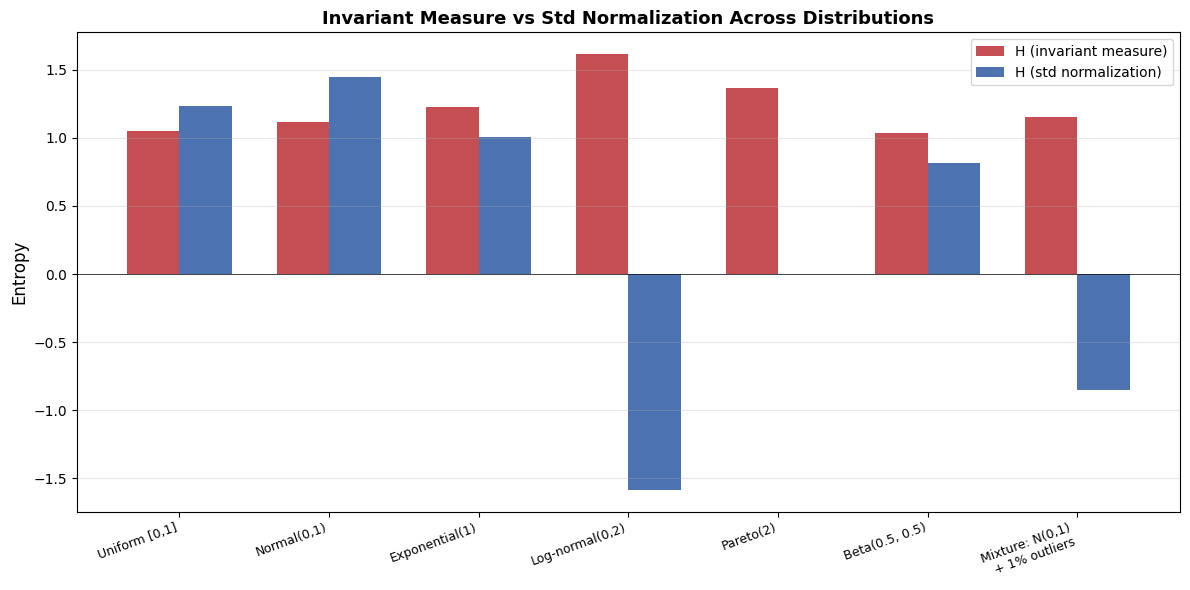

In [5]:
fig, ax = plt.subplots(figsize=(12, 6))

x_pos = np.arange(len(names))
width = 0.35

bars1 = ax.bar(x_pos - width / 2, h_inv_vals, width, label="H (invariant measure)", color="#C44E52")
bars2 = ax.bar(x_pos + width / 2, h_std_vals, width, label="H (std normalization)", color="#4C72B0")

ax.set_xticks(x_pos)
ax.set_xticklabels([n.replace(" + 1% outliers at 100", "\n+ 1% outliers") for n in names],
                    fontsize=9, rotation=20, ha="right")
ax.set_ylabel("Entropy", fontsize=12)
ax.set_title("Invariant Measure vs Std Normalization Across Distributions", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.axhline(y=0, color="black", linewidth=0.5)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

## 3. Why the difference? Visualizing the normalizations

For a heavy-tailed distribution like log-normal, `std` is dominated by the tail,
so dividing by `std` crushes the bulk of the data near zero.
The invariant measure reflects the actual **local spacing**, keeping the data structure intact.

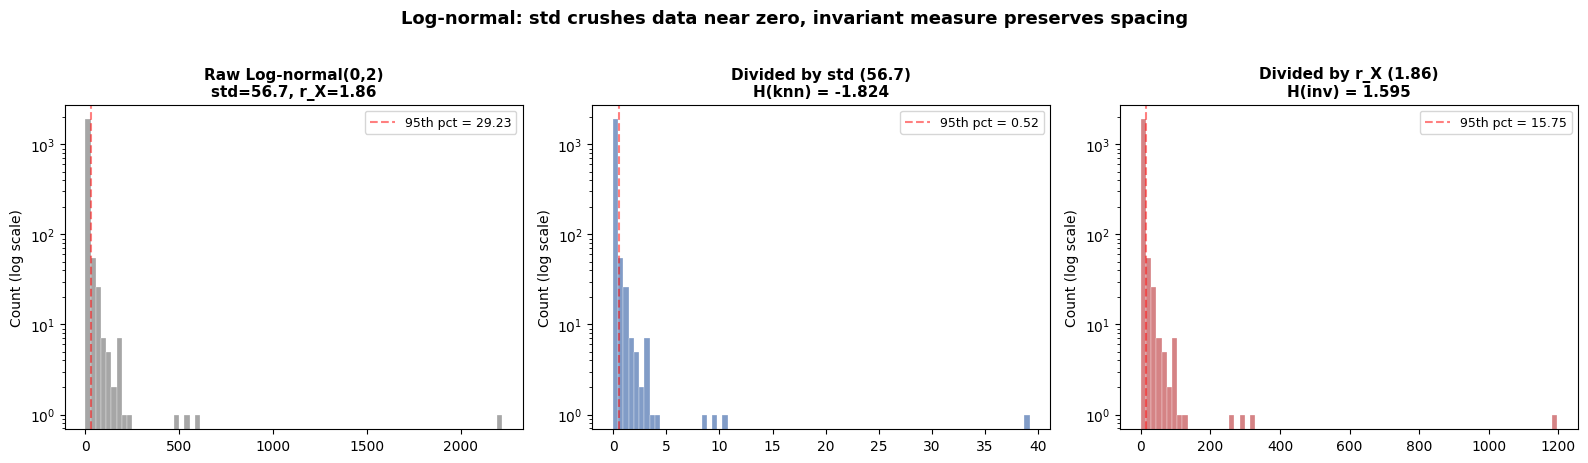

std / r_X ratio = 30.5x
std is 30.5x larger than the invariant measure for log-normal data
This means dividing by std compresses the data 30.5x more than dividing by r_X


In [6]:
np.random.seed(42)
n = 2000
x_ln = np.random.lognormal(0, 2, n)

std_x = np.std(x_ln)
r_x = compute_invariant_measure(x_ln)

x_by_std = x_ln / std_x
x_by_inv = x_ln / r_x

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, data, title, color in [
    (axes[0], x_ln, f"Raw Log-normal(0,2)\nstd={std_x:.1f}, r_X={r_x:.2f}", "gray"),
    (axes[1], x_by_std, f"Divided by std ({std_x:.1f})\nH(knn) = {entropy_std_normalized(x_ln):.3f}", "#4C72B0"),
    (axes[2], x_by_inv, f"Divided by r_X ({r_x:.2f})\nH(inv) = {entropy(x_ln, method='inv'):.3f}", "#C44E52"),
]:
    ax.hist(data, bins=80, color=color, alpha=0.7, edgecolor="white", linewidth=0.3)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_ylabel("Count (log scale)")
    ax.set_yscale("log")  # linear y hides the tail: 95%+ of points land in 1-2 bins
    # Show where most data lives
    p95 = np.percentile(data, 95)
    ax.axvline(p95, color="red", linestyle="--", alpha=0.5, label=f"95th pct = {p95:.2f}")
    ax.legend(fontsize=9)

fig.suptitle("Log-normal: std crushes data near zero, invariant measure preserves spacing",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print(f"std / r_X ratio = {std_x / r_x:.1f}x")
print(f"std is {std_x / r_x:.1f}x larger than the invariant measure for log-normal data")
print(f"This means dividing by std compresses the data {std_x / r_x:.1f}x more than dividing by r_X")

## 4. Robustness to outliers

A few extreme outliers inflate `std` dramatically while barely affecting `median(nn_dist)`.

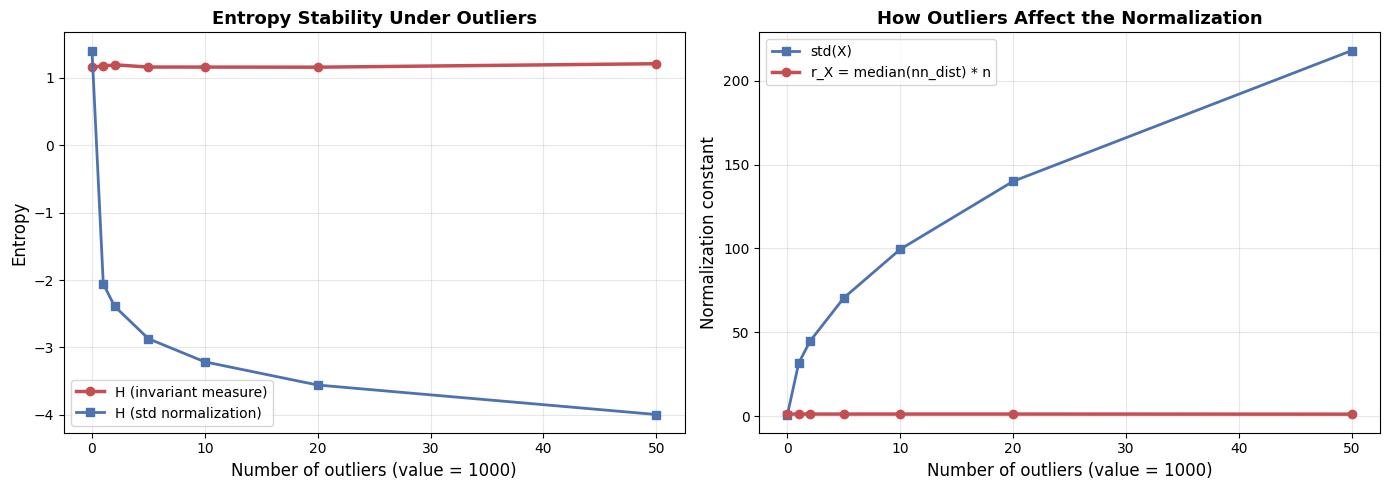


With 50 outliers at 1000:
  std inflates from 0.98 to 217.94 (222.7x)
  r_X changes from 1.2505 to 1.1943 (0.96x)


In [7]:
np.random.seed(42)
n = 1000
x_clean = np.random.randn(n)

outlier_counts = [0, 1, 2, 5, 10, 20, 50]
h_inv_out = []
h_std_out = []
std_vals = []
rx_vals = []

for n_out in outlier_counts:
    x = x_clean.copy()
    if n_out > 0:
        # Replace first n_out points with extreme outliers
        x[:n_out] = 1000
    h_inv_out.append(entropy(x, method="inv"))
    h_std_out.append(entropy_std_normalized(x))
    std_vals.append(np.std(x))
    rx_vals.append(compute_invariant_measure(x))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: entropy estimates
ax = axes[0]
ax.plot(outlier_counts, h_inv_out, "o-", label="H (invariant measure)", color="#C44E52", linewidth=2.5)
ax.plot(outlier_counts, h_std_out, "s-", label="H (std normalization)", color="#4C72B0", linewidth=2)
ax.set_xlabel("Number of outliers (value = 1000)", fontsize=12)
ax.set_ylabel("Entropy", fontsize=12)
ax.set_title("Entropy Stability Under Outliers", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Right: normalization constants
ax2 = axes[1]
ax2.plot(outlier_counts, std_vals, "s-", label="std(X)", color="#4C72B0", linewidth=2)
ax2.plot(outlier_counts, rx_vals, "o-", label="r_X = median(nn_dist) * n", color="#C44E52", linewidth=2.5)
ax2.set_xlabel("Number of outliers (value = 1000)", fontsize=12)
ax2.set_ylabel("Normalization constant", fontsize=12)
ax2.set_title("How Outliers Affect the Normalization", fontsize=13, fontweight="bold")
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nWith 50 outliers at 1000:")
print(f"  std inflates from {std_vals[0]:.2f} to {std_vals[-1]:.2f} ({std_vals[-1]/std_vals[0]:.1f}x)")
print(f"  r_X changes from {rx_vals[0]:.4f} to {rx_vals[-1]:.4f} ({rx_vals[-1]/rx_vals[0]:.2f}x)")

## 5. Stability across sample sizes

How consistent is each method as we vary $n$?

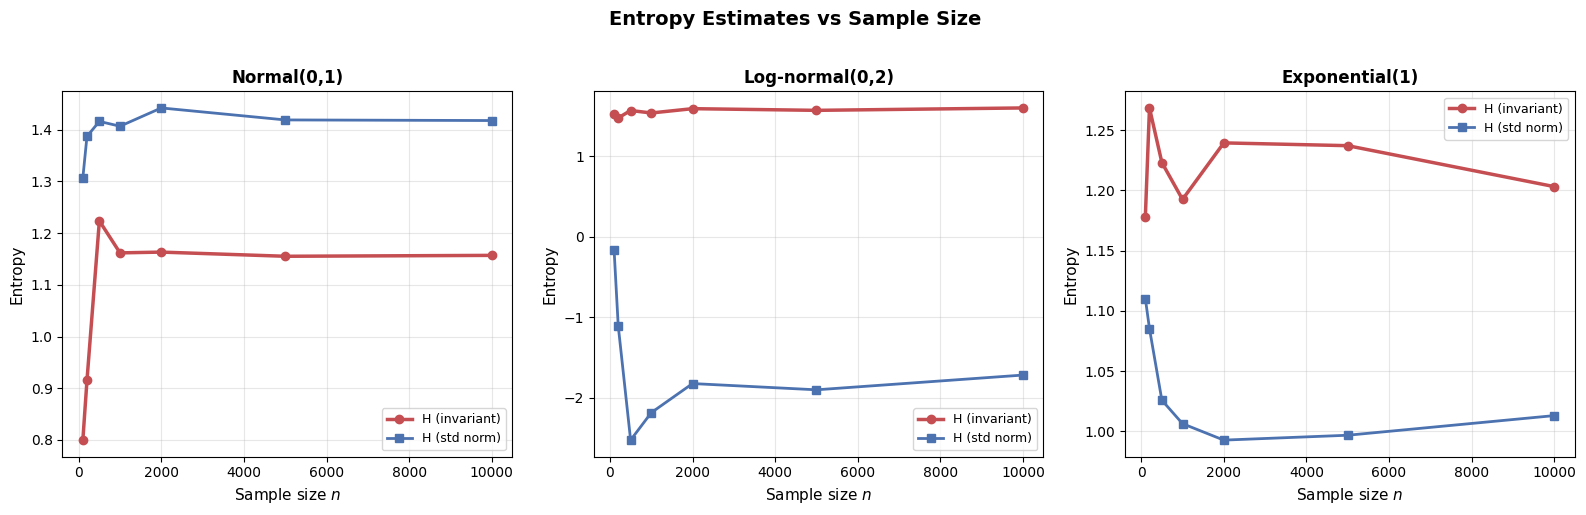

In [8]:
sample_sizes = [100, 200, 500, 1000, 2000, 5000, 10000]

dist_generators = {
    "Normal(0,1)": lambda n: np.random.randn(n),
    "Log-normal(0,2)": lambda n: np.random.lognormal(0, 2, n),
    "Exponential(1)": lambda n: np.random.exponential(1, n),
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (dist_name, gen) in zip(axes, dist_generators.items()):
    h_inv_n = []
    h_std_n = []
    for ns in sample_sizes:
        np.random.seed(42)
        x = gen(ns)
        h_inv_n.append(entropy(x, method="inv"))
        h_std_n.append(entropy_std_normalized(x))

    ax.plot(sample_sizes, h_inv_n, "o-", label="H (invariant)", color="#C44E52", linewidth=2.5)
    ax.plot(sample_sizes, h_std_n, "s-", label="H (std norm)", color="#4C72B0", linewidth=2)
    ax.set_xlabel("Sample size $n$", fontsize=11)
    ax.set_ylabel("Entropy", fontsize=11)
    ax.set_title(dist_name, fontsize=12, fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle("Entropy Estimates vs Sample Size", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 6. About negative entropy

Differential entropy **can** be negative — unlike discrete entropy, it measures information
relative to a continuous reference measure. Neither normalization guarantees positivity
for all distributions.

However, the invariant measure produces less extreme values on pathological distributions:

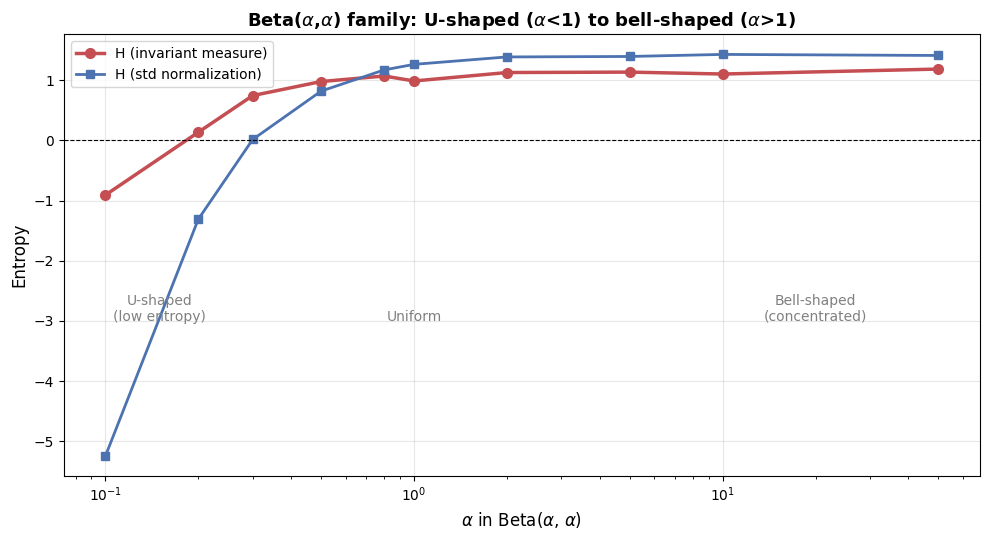

Both methods go negative for Beta(0.1, 0.1) — this distribution is almost discrete.
The invariant measure produces less extreme values across the entire family.


In [9]:
np.random.seed(42)
n = 2000

# Beta(a, a) family: from U-shaped (a<1) to bell-shaped (a>1)
alphas = [0.1, 0.2, 0.3, 0.5, 0.8, 1.0, 2.0, 5.0, 10.0, 50.0]
h_inv_beta = []
h_std_beta = []

for a in alphas:
    x = np.random.beta(a, a, n)
    h_inv_beta.append(entropy(x, method="inv"))
    h_std_beta.append(entropy_std_normalized(x))

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(alphas, h_inv_beta, "o-", label="H (invariant measure)", color="#C44E52", linewidth=2.5, markersize=7)
ax.plot(alphas, h_std_beta, "s-", label="H (std normalization)", color="#4C72B0", linewidth=2, markersize=6)
ax.axhline(y=0, color="black", linewidth=0.8, linestyle="--")
ax.set_xscale("log")
ax.set_xlabel(r"$\alpha$ in Beta($\alpha$, $\alpha$)", fontsize=12)
ax.set_ylabel("Entropy", fontsize=12)
ax.set_title(r"Beta($\alpha$,$\alpha$) family: U-shaped ($\alpha$<1) to bell-shaped ($\alpha$>1)",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Annotate regions
ax.annotate("U-shaped\n(low entropy)", xy=(0.15, -3), fontsize=10, ha="center", color="gray")
ax.annotate("Uniform", xy=(1.0, -3), fontsize=10, ha="center", color="gray")
ax.annotate("Bell-shaped\n(concentrated)", xy=(20, -3), fontsize=10, ha="center", color="gray")

plt.tight_layout()
plt.show()

print("Both methods go negative for Beta(0.1, 0.1) — this distribution is almost discrete.")
print("The invariant measure produces less extreme values across the entire family.")

## 6.5 When does the choice of normalization actually matter?

It's fair to ask: on the table in section 2, `H(std)` and `H(inv)` are within
**~0.2-0.4 nats of each other for Uniform, Normal, Exponential, and Beta(0.5,0.5)** --
i.e. std-normalization looks perfectly fine on "nice" data. The two methods only
diverge sharply on the pathological cases that motivate this package:

| Distribution | H(inv) | H(std) | gap |
|---|---:|---:|---:|
| Log-normal(0,2) | 1.61 | -1.58 | 3.2 nats |
| Pareto(2) | 1.37 | -0.00 | 1.4 nats |
| Mixture + 1% outliers at 100 | 1.15 | -0.85 | 2.0 nats |

That's the honest scope of the claim: **not** "std-normalization is broken", but
"std is a global L2 statistic, so a handful of extreme points (or a heavy tail) can
dominate it and silently distort every entropy estimate downstream, whereas the
median-based invariant measure barely moves". Section 4's outlier sweep makes this
concrete: 50 extreme points inflate `std` by **222x** while `r_X` changes by less
than 4%.


## Summary

| Property | Invariant measure | Std normalization |
|---|---|---|
| **Scale invariance** | Yes | Yes |
| **Type** | Local (median nn-distance) | Global (L2 norm) |
| **Robust to outliers** | Yes (median-based) | No (variance-based) |
| **Heavy-tailed data** | Preserves local structure | Over-compresses bulk |
| **Always positive** | No (but less extreme) | No (more extreme negatives) |
| **Entropy values** | Stable, narrow range | Wider swings across distributions |

### Key insight

Both normalizations achieve scale invariance. The difference is in **what they preserve**:

- `std` measures global spread — sensitive to outliers and heavy tails
- `median(nn_dist) * n` measures local spacing — reflects the actual density structure

For well-behaved (Gaussian-like) data, they give similar results. The invariant measure
shines on **skewed, heavy-tailed, or outlier-contaminated** data where `std` is a poor
summary of the distribution's structure.